# 07 · Practical Approximations: MC Dropout and Deep Ensembles (PyTorch)

*Companion notebook for the chapter section* **Approximations for Estimation**

Full BNNs are expensive. Two cheap methods give useful uncertainty from almost-ordinary networks and are the most widely used in practice:

* **Monte Carlo dropout** — keep dropout switched on at prediction time. Gal & Ghahramani (2016) showed this is approximate variational inference (Gal, 2016, *Uncertainty in Deep Learning*).
* **Deep ensembles** — train several networks from different random initialisations and average them (Lakshminarayanan et al., 2017).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

rng = np.random.default_rng(2)
x_np = np.concatenate([rng.uniform(-4, -1.5, 60), rng.uniform(1.5, 4, 60)])
y_np = np.sin(x_np) + 0.1 * rng.standard_normal(len(x_np))
x_t = torch.tensor(x_np, dtype=torch.float32)[:, None]
y_t = torch.tensor(y_np, dtype=torch.float32)
xg = torch.linspace(-8, 8, 400)[:, None]; xs = xg.squeeze().numpy()

## 1. MC dropout

**Dropout** multiplies each hidden unit by a Bernoulli$(1-p)$ mask during training. Normally masks are switched off at test time. If we **keep them on** and run $T$ forward passes, each pass uses a different thinned network — a sample from an implicit approximate posterior $q(\mathbf w)$.

In the variational interpretation the weight decay plays the role of the prior, and the dropout rate $p$ controls the width of $q$.

In [2]:
class DropoutNet(nn.Module):
    def __init__(self, hidden=128, p=0.1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, 1))
    def forward(self, x):
        return self.body(x).squeeze(-1)

def train(model, steps=3000, lr=5e-3, wd=1e-4):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    model.train()
    for _ in range(steps):
        opt.zero_grad(); F.mse_loss(model(x_t), y_t).backward(); opt.step()
    return model

mcd = train(DropoutNet())

@torch.no_grad()
def mc_predict(model, x, T=300):
    model.train()                                # <- the whole trick: dropout stays ON
    return torch.stack([model(x) for _ in range(T)]).numpy()

S_mcd = mc_predict(mcd, xg)
mcd.eval()
with torch.no_grad():
    y_eval = mcd(xg).numpy()                     # standard deterministic prediction for comparison

## 2. Deep ensemble

In [3]:
class MLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(1, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
    def forward(self, x):
        return self.body(x).squeeze(-1)

ensemble = []
for seed in range(8):
    torch.manual_seed(seed)
    ensemble.append(train(MLP()))

with torch.no_grad():
    S_ens = torch.stack([m(xg) for m in ensemble]).numpy()

## 3. Side by side
Since these networks were trained with MSE they do not model the noise; we add the known noise variance $0.1^2$ to obtain the total predictive band. (Exercise 2 learns it instead.)

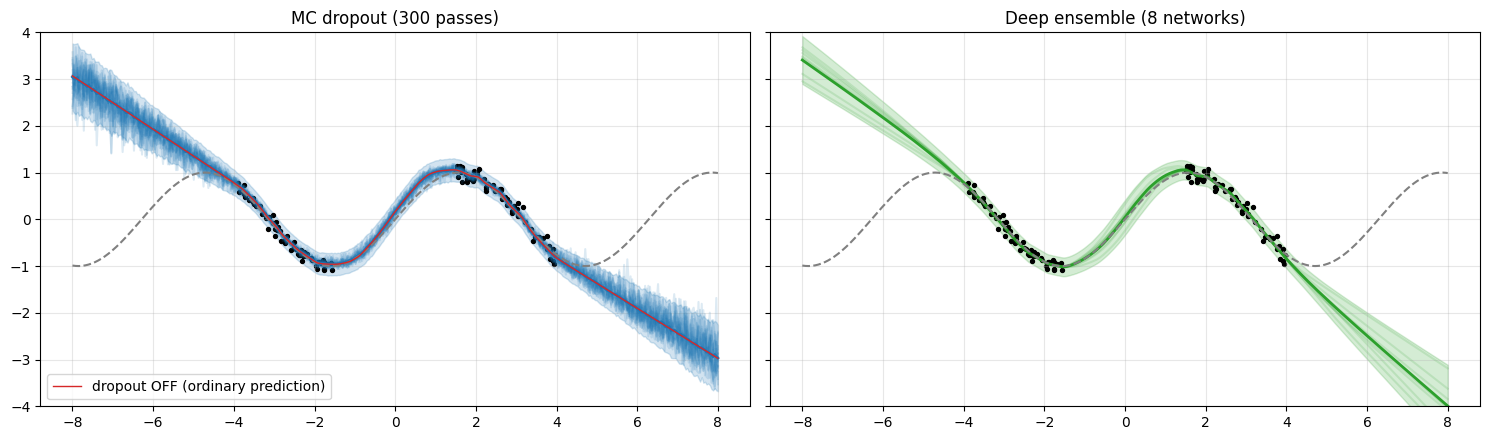

In [4]:
noise = 0.1
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, S, name, c in [(axes[0], S_mcd, "MC dropout (300 passes)", "C0"), (axes[1], S_ens, "Deep ensemble (8 networks)", "C2")]:
    mu, sd = S.mean(0), np.sqrt(S.std(0) ** 2 + noise**2)
    for s in S[:20]:
        ax.plot(xs, s, c=c, alpha=0.15)
    ax.fill_between(xs, mu - 2 * sd, mu + 2 * sd, color=c, alpha=0.2)
    ax.plot(xs, mu, c=c, lw=2)
    ax.scatter(x_np, y_np, c="k", s=8); ax.plot(xs, np.sin(xs), "--", c="gray")
    ax.set_title(name); ax.set_ylim(-4, 4)
axes[0].plot(xs, y_eval, c="C3", lw=1, label="dropout OFF (ordinary prediction)"); axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

## 4. Are the uncertainties honest? Checking coverage

A 95% predictive interval should contain the truth about 95% of the time. We test on fresh points from three regions: **inside** the data, in the **gap**, and **outside** the data range.

In [5]:
def coverage(S, x_test, y_test, noise=0.1):
    mu, sd = S.mean(0), np.sqrt(S.std(0) ** 2 + noise**2)
    inside = np.abs(y_test - mu) <= 1.96 * sd
    return inside.mean(), sd.mean()

regions = {"inside data": np.concatenate([rng.uniform(-4, -1.5, 500), rng.uniform(1.5, 4, 500)]),
           "gap (-1.5, 1.5)": rng.uniform(-1.5, 1.5, 1000),
           "outside (4, 7)": rng.uniform(4, 7, 1000)}

print(f"{'region':18s} {'method':15s} {'coverage':>9s} {'mean sd':>8s}")
for rname, xr in regions.items():
    yr = np.sin(xr) + noise * rng.standard_normal(len(xr))
    xr_t = torch.tensor(xr, dtype=torch.float32)[:, None]
    with torch.no_grad():
        S1 = mc_predict(mcd, xr_t, T=200)
        S2 = torch.stack([m(xr_t) for m in ensemble]).numpy()
    for mname, S in [("MC dropout", S1), ("ensemble", S2)]:
        cov, sd = coverage(S, xr, yr)
        print(f"{rname:18s} {mname:15s} {cov:9.2%} {sd:8.3f}")

region             method           coverage  mean sd


inside data        MC dropout         97.20%    0.117
inside data        ensemble           94.30%    0.101


gap (-1.5, 1.5)    MC dropout         89.60%    0.130
gap (-1.5, 1.5)    ensemble           97.40%    0.143


outside (4, 7)     MC dropout         29.40%    0.219
outside (4, 7)     ensemble            8.90%    0.209


Inside the data both methods are roughly calibrated. Outside the data range the band does widen, but **far too little**: coverage collapses well below 95%, because ReLU networks extrapolate *linearly* and all members/dropout masks agree on that line. These methods are *approximations*, and their uncertainty far from the data can be badly over-confident (compare MCMC in notebook 05). Coverage checks like this one should be part of every UQ project.

## 5. Comparison of the approximations in this course

| method | cost | quality of uncertainty | change to a normal network |
|---|---|---|---|
| MCMC (05) | very high | best (asymptotically exact) | new training loop |
| Bayes by Backprop (06) | ~2× parameters | good in-distribution, over-confident far away | new layers |
| MC dropout (07) | almost free | depends strongly on $p$ | none (keep dropout on) |
| Deep ensemble (07) | $M\times$ training | often the strongest in practice | none (train $M$ times) |

## Exercises
1. Vary the dropout rate $p\in\{0.01, 0.1, 0.3\}$. How do the band width and the in-data fit change?
2. Make each ensemble member output a mean and a variance and train with the Gaussian negative log-likelihood (`F.gaussian_nll_loss`). This captures **aleatoric** noise, as in Lakshminarayanan et al. (2017).
3. Replace ReLU by tanh. Which activation extrapolates with more uncertainty, and why?